# **import libraries**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split, Dataset
from torchmetrics import Accuracy

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder


from torchvision import transforms as T


import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import glob

from PIL import Image

from tqdm import tqdm

import numpy as np
import pandas as pd

# **custom Dataset**

In [2]:
trainTransform = T.Compose([T.Resize((128,128)),
                            T.RandomPerspective(),
                            T.RandAugment(),
                            T.ToTensor(),
                            T.Normalize(mean=[0.485, 0.456, 0.406],
                                        std=[0.229, 0.224, 0.225])])
testTransform = T.Compose([T.Resize((128,128)),
                           T.ToTensor(),
                           T.Normalize(mean=[0.485, 0.456, 0.406],
                                       std=[0.229, 0.224, 0.225])])

In [3]:
class Food(Dataset):
    def __init__(self, root=r"E:\food\food\train", phase="Train", trainSize=0.80, random_state=23, transform=None):
        mainAddress = root
        self.tempImagesList = []
        nameLabels = []
        self.tempLabels = []
        
        for folder in glob.glob(f"{mainAddress}\*"):
            for imageFile in glob.glob(f"{folder}\*"):
                self.tempImagesList.append(imageFile)
                nameLabels.append(imageFile.split('\\')[-2])
        oe = OrdinalEncoder()        
        self.tempLabels = oe.fit_transform(pd.DataFrame(nameLabels)).reshape(-1)
        self.tempLabels = torch.tensor(self.tempLabels, dtype=torch.long)

        
        x_train, x_test, y_train, y_test= train_test_split(self.tempImagesList, self.tempLabels , train_size=trainSize, random_state=random_state)

        if phase == "Train":
            self.imagesList = x_train
            self.labels = y_train
        else:
            self.imagesList = x_test
            self.labels = y_test
        self.transform = transform
        
    def __getitem__(self, item):
        imagePath = self.imagesList[item]
        img = Image.open(imagePath).convert('RGB')
        label = self.labels[item]
        img = self.transform(img)
        
        return img, label

    def __len__(self):
        return len(self.imagesList)

In [4]:
trainSet = Food(phase="Train", transform=trainTransform)
testSet = Food(phase="Test", transform=testTransform)

In [5]:
print(len(trainSet))
print(len(testSet))

14041
3511


# **DataLoader**

In [6]:
trainLoader = DataLoader(trainSet, batch_size=32, shuffle=True)
testLoader = DataLoader(testSet, batch_size=32, shuffle=False)

In [7]:
x_batch, y_batch = next(iter(trainLoader))

In [8]:
trainTensorDataset = TensorDataset(x_batch,y_batch)

In [9]:
x_batch.shape, y_batch.shape

(torch.Size([32, 3, 128, 128]), torch.Size([32]))

# **Build model**

In [10]:
def conv(in_channels, out_channels):
    subModel = nn.Sequential(nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=(3,3), padding=1),
                  nn.BatchNorm2d(out_channels),
                  nn.ReLU())
    return subModel

In [20]:
model = nn.Sequential(
    conv(3,64),
    conv(64,64),
    conv(64,64),
    nn.MaxPool2d((3,3), padding=1, stride=2), #64x64x64

    conv(64,128),
    conv(128,128),
    conv(128,128),
    nn.MaxPool2d((3,3), padding=1, stride=2), #128x32x32

    conv(128,256),
    conv(256,256),
    conv(256,256),
    nn.MaxPool2d((3,3), padding=1, stride=2), #256x16x16

    conv(256,512),
    conv(512,512),
    conv(512,512),
    nn.MaxPool2d((3,3), padding=1, stride=2), #512x8x8

    nn.AdaptiveAvgPool2d((1,1)), #512x1x1

    nn.Flatten(),

    nn.Linear(512,21)
)

In [21]:
def num_params(model):
    nums = sum(p.numel() for p in model.parameters())
    return f"{nums:,}"

In [22]:
num_params(model)

'7,836,309'

# **To device**

In [23]:
if torch.cuda.is_available() == True:
    device = 'cuda'
else:
    device = 'cpu'
model = model.to(device)

# **Loss and Optimizer**

In [32]:
lossCEL = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# **Utils**

In [25]:
class AverageMeter(object):
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

In [26]:
def train_one_epoch(model, trainLoader, lossFn, optimizer, numCls, epoch=None):
    model.train()
    lossTrain = AverageMeter()
    if numCls > 2:
        accTrain = Accuracy(task='multiclass', num_classes=numCls).to(device)
    elif numCls == 2:
        accTrain = Accuracy(task='binary').to(device)
    else:
        raise ValueError(f"numCls must be bigger than 1")
        
    with tqdm(trainLoader, unit='batch') as tepoch:
        for (inputs, targets) in tepoch:
            if epoch != None:
                tepoch.set_description_str(f'Epoch {epoch}')

            
            inputs = inputs.to(device)
            targets = targets.to(device)

            
            outputs = model(inputs)

            
            loss = lossFn(outputs.squeeze(), targets)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            
            lossTrain.update(loss.item())
            accTrain(outputs.squeeze(), targets.int())
            tepoch.set_postfix(loss=lossTrain.avg, accuracy=100.0 * accTrain.compute().item())
    return model, lossTrain.avg, accTrain.compute().item()

In [27]:
def evaluate(model, validLoader, lossFn, numCls):
    model.eval()
    with torch.no_grad():
        lossValid = AverageMeter()
        if numCls > 2:
            accValid = Accuracy(task='multiclass', num_classes=numCls).to(device)
        elif numCls == 2:
            accValid = Accuracy(task='binary').to(device)
        else:
            raise ValueError(f"numCls must be bigger than 1")
        for inputs, targets in validLoader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            outputs = model(inputs)
            loss = lossFn(outputs.squeeze(), targets)
            lossValid.update(loss.item())
            accValid(outputs.squeeze(), targets.int())
    return lossValid.avg, accValid.compute().item()

# **Train model**

In [28]:
loss_train_hist = []
loss_valid_hist = []

acc_train_hist = []
acc_valid_hist = []
epoch_counter = 0
best_loss_valid = torch.inf

In [33]:
num_epochs = 5
for epoch in range(1,(num_epochs+1)):
    # Train
    model, loss_train, acc_train = train_one_epoch(model, trainLoader, lossCEL, optimizer, 21, epoch)
    # Validation
    loss_valid, acc_valid = evaluate(model, testLoader, lossCEL, 21)
    loss_train_hist.append(loss_train)
    loss_valid_hist.append(loss_valid)
    
    acc_train_hist.append(acc_train)
    acc_valid_hist.append(acc_valid)

    if loss_valid < best_loss_valid:
        torch.save(model, f'model.pt')
        best_loss_valid = loss_valid
        
    print(f'Test: Loss = {loss_valid:.4f}, Acc = {100.0 * acc_valid:.4f}')
    print()
    epoch_counter += 1

Epoch 1: 100%|█████████████████████████████████████████| 439/439 [04:22<00:00,  1.67batch/s, accuracy=79.7, loss=0.684]


Valid: Loss = 0.7327, Acc = 79.2367



Epoch 2: 100%|█████████████████████████████████████████| 439/439 [04:21<00:00,  1.68batch/s, accuracy=81.4, loss=0.606]


Valid: Loss = 0.7361, Acc = 79.5785



Epoch 3: 100%|█████████████████████████████████████████| 439/439 [04:20<00:00,  1.68batch/s, accuracy=82.9, loss=0.571]


Valid: Loss = 0.7331, Acc = 79.0943



Epoch 4: 100%|█████████████████████████████████████████| 439/439 [04:20<00:00,  1.69batch/s, accuracy=83.4, loss=0.558]


Valid: Loss = 0.7307, Acc = 79.4645



Epoch 5: 100%|█████████████████████████████████████████| 439/439 [04:21<00:00,  1.68batch/s, accuracy=83.5, loss=0.539]


Valid: Loss = 0.7198, Acc = 80.4614



# **Save Model**

In [34]:
torch.save(model, f'foodModel.pt')

# **PLT**

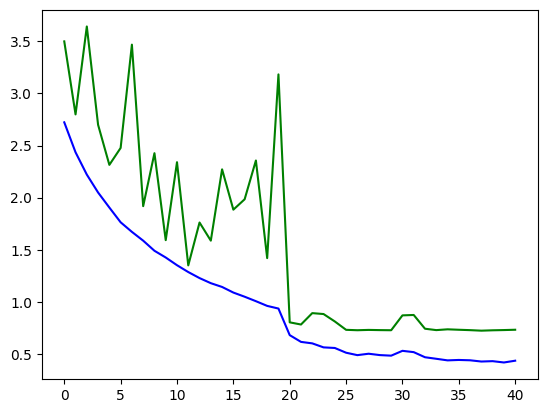

In [40]:
fig, ax = plt.subplots()
ax.plot(range(epoch_counter), loss_train_hist,c='b')
ax.plot(range(epoch_counter), loss_valid_hist,c='g')